**Data Understanding & Cleaning**

In [1]:
#import library untuk analisis, visualisasi, dan modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
#load dataset dari folder ke dataframe

file_path = "/content/instax_sales_transaction_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded.")
print(f"Total baris: {df.shape[0]}")
print(f"Total kolom: {df.shape[1]} \n")

Dataset loaded.
Total baris: 12334
Total kolom: 12 



In [3]:
#Menampilkan informasi awal dataset

print("Sample Data")
display(df.head())

print("Info Data")
df.info()

print("Deskripsi Data")
display(df.describe().T)

print("Deskripsi Kategorikal")
display(df.describe(include='object').T)

print("Nilai Unik Setiap Kolom")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
print()

print("Missing Values")
missing = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
display(pd.DataFrame({"Missing": missing, "Percent (%)": missing_percent}))

Sample Data


,Tanggal,Tahun,Bulan,Hari,Kategori,Nama_Produk,Lokasi_Toko,Metode_Bayar,Harga_Satuan,Qty,Diskon_IDR,Total_Penjualan
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,9250,175750
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,0,185000
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000
3,2022-05-01,2022,5,Sunday,Kamera,Instax Mini 11,Shopee Mall,Paylater,1100000,1,0,1100000
4,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000


Info Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12334 entries, 0 to 12333
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Tanggal          12334 non-null  object
 1   Tahun            12334 non-null  int64 
 2   Bulan            12334 non-null  int64 
 3   Hari             12334 non-null  object
 4   Kategori         12334 non-null  object
 5   Nama_Produk      12334 non-null  object
 6   Lokasi_Toko      12334 non-null  object
 7   Metode_Bayar     12334 non-null  object
 8   Harga_Satuan     12334 non-null  int64 
 9   Qty              12334 non-null  int64 
 10  Diskon_IDR       12334 non-null  int64 
 11  Total_Penjualan  12334 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 1.1+ MB
Deskripsi Data


,count,mean,std,min,25%,50%,75%,max
Tahun,12334.0,2023.485244,0.928167,2022.0,2023.0,2024.0,2024.0,2025.0
Bulan,12334.0,6.790011,3.872200,1.0,3.0,7.0,10.0,12.0
Harga_Satuan,12334.0,398907.086103,691500.220342,50000.0,95000.0,150000.0,185000.0,2900000.0
Qty,12334.0,1.940814,1.151353,1.0,1.0,2.0,3.0,5.0
Diskon_IDR,12334.0,12908.991406,46182.404210,0.0,0.0,0.0,7500.0,1160000.0
Total_Penjualan,12334.0,520571.225880,703337.914195,40000.0,150000.0,270750.0,527250.0,5800000.0


Deskripsi Kategorikal


,count,unique,top,freq
Tanggal,12334,1096,2024-12-01,48
Hari,12334,7,Sunday,2209
Kategori,12334,3,Film,7386
Nama_Produk,12334,10,Instax Mini Film (20s),2518
Lokasi_Toko,12334,5,Surabaya Branch,2514
Metode_Bayar,12334,4,Transfer Bank,3159


Nilai Unik Setiap Kolom
Tanggal: 1096 unique values
Tahun: 4 unique values
Bulan: 12 unique values
Hari: 7 unique values
Kategori: 3 unique values
Nama_Produk: 10 unique values
Lokasi_Toko: 5 unique values
Metode_Bayar: 4 unique values
Harga_Satuan: 9 unique values
Qty: 5 unique values
Diskon_IDR: 58 unique values
Total_Penjualan: 106 unique values

Missing Values


,Missing,Percent (%)
Tanggal,0,0.0
Tahun,0,0.0
Bulan,0,0.0
Hari,0,0.0
Kategori,0,0.0
Nama_Produk,0,0.0
Lokasi_Toko,0,0.0
Metode_Bayar,0,0.0
Harga_Satuan,0,0.0
Qty,0,0.0


In [4]:
# Konsistensi data

print("Konsistensi Nilai Total Penjualan")

df["Cek_Total"] = (df["Harga_Satuan"] * df["Qty"]) - df["Diskon_IDR"]

df["Selisih"] = df["Total_Penjualan"] - df["Cek_Total"]

inkonsisten = df[df["Selisih"] != 0]

print(f"Jumlah transaksi tidak konsisten: {inkonsisten.shape[0]}")
if inkonsisten.shape[0] > 0:
    display(inkonsisten.head())

df.drop(["Cek_Total", "Selisih"], axis=1, inplace=True)

Konsistensi Nilai Total Penjualan
Jumlah transaksi tidak konsisten: 0


In [5]:
#Cek outlier awal

num_cols = ["Harga_Satuan", "Qty", "Diskon_IDR", "Total_Penjualan"]

print("Statistik Awal OUtlier")
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outlier_count} potensi outlier")

Statistik Awal OUtlier
Harga_Satuan: 1855 potensi outlier
Qty: 0 potensi outlier
Diskon_IDR: 1697 potensi outlier
Total_Penjualan: 1730 potensi outlier


In [6]:
#Pembersihan data

duplicates = df.duplicated().sum()
print(f"Duplikasi ditemukan: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplikasi dihapus.")
else:
    print("Tidak ada duplikasi.")

try:
    df["Tanggal"] = pd.to_datetime(df["Tanggal"])
    print("Kolom 'Tanggal' berhasil dikonversi ke datetime.")
except:
    print("Kolom 'Tanggal' gagal dikonversi (cek format).")

cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print("Pembersihan penulisan kategori selesai.")

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values sudah ditangani.")

Duplikasi ditemukan: 129
Duplikasi dihapus.
Kolom 'Tanggal' berhasil dikonversi ke datetime.
Pembersihan penulisan kategori selesai.
Missing values sudah ditangani.


In [7]:
# Validasi akhir hasil dari pembersihan data

print("Validasi")
display(df.isnull().sum())

print("Sample Dataset Setelah Cleaning")
display(df.head())

print("Ringkasan")
print(f"Jumlah baris final: {df.shape[0]}")
print(f"Jumlah kolom final: {df.shape[1]}")
print("Numerik:", list(num_cols))
print("Kategorikal:", list(cat_cols))

Validasi


,0
Tanggal,0
Tahun,0
Bulan,0
Hari,0
Kategori,0
Nama_Produk,0
Lokasi_Toko,0
Metode_Bayar,0
Harga_Satuan,0
Qty,0


Sample Dataset Setelah Cleaning


,Tanggal,Tahun,Bulan,Hari,Kategori,Nama_Produk,Lokasi_Toko,Metode_Bayar,Harga_Satuan,Qty,Diskon_IDR,Total_Penjualan
0,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,9250,175750
1,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Tokopedia Official,Kartu Kredit,185000,1,0,185000
2,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (20s),Shopee Mall,E-Wallet (Gopay/OVO),185000,2,0,370000
3,2022-05-01,2022,5,Sunday,Kamera,Instax Mini 11,Shopee Mall,Paylater,1100000,1,0,1100000
5,2022-05-01,2022,5,Sunday,Film,Instax Mini Film (10s),Tokopedia Official,Kartu Kredit,95000,1,4750,90250


Ringkasan
Jumlah baris final: 12205
Jumlah kolom final: 12
Numerik: ['Tahun', 'Bulan', 'Harga_Satuan', 'Qty', 'Diskon_IDR', 'Total_Penjualan']
Kategorikal: ['Hari', 'Kategori', 'Nama_Produk', 'Lokasi_Toko', 'Metode_Bayar']


**Exploratory Data Analysis (EDA Insight)**

In [8]:
#Konfigurasi style visualisasi

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)

In [9]:
#Analisis tren total penjualan per bulan transaksi

import plotly.express as px

# Aggregate data by month
df_monthly = df.set_index('Tanggal').resample('MS')['Total_Penjualan'].sum().reset_index()
df_monthly.rename(columns={'Tanggal': 'Bulan'}, inplace=True)

# Convert Total_Penjualan to millions (Juta)
df_monthly['Total_Penjualan_Juta'] = df_monthly['Total_Penjualan'] / 1_000_000

df_monthly = df_monthly.set_index('Bulan')

# Exclude data tanggal 01-05-2025 karena bulan Mei 2025 hanya memiliki 1 hari data,
# sehingga total revenue bulan itu tidak representatif dan akan membuat line chart terlihat turun drastis.

df_plot = df_monthly[df_monthly.index != pd.to_datetime('2025-05-01')]

# Plotly line chart tanpa 01-05-2025

fig = px.line(
df_plot,
x=df_plot.index,
y='Total_Penjualan_Juta',
title='Total Revenue per Month',
labels={'x':'Bulan', 'Total_Penjualan_Juta':'Total Penjualan (Juta)'}
)

fig.update_traces(mode='lines+markers')  # titik di setiap bulan
fig.update_layout(xaxis_tickformat='%b %Y')  # format bulan+tahun
fig.show()

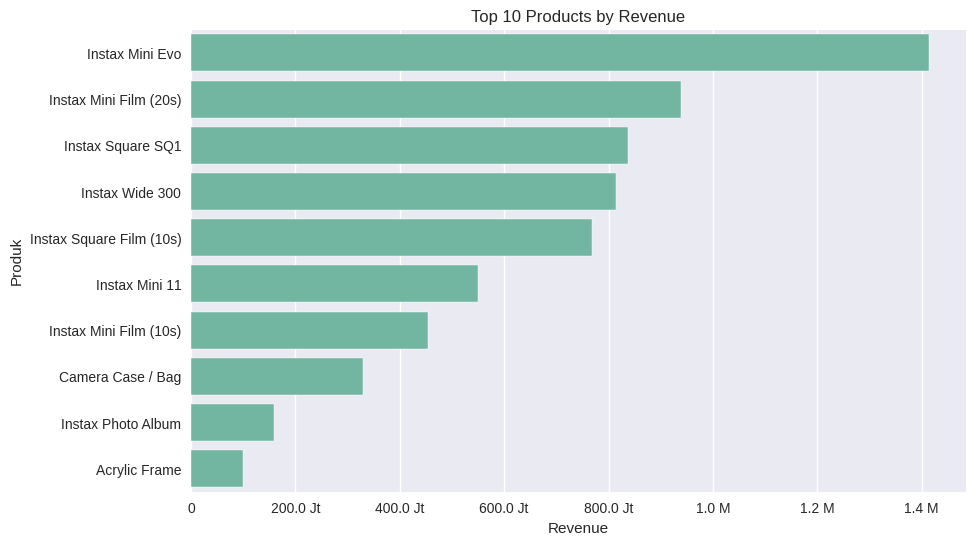

In [10]:
#Identifikasi 10 produk terlaris berdasarkan total penjualan

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

top_prod = (
    df.groupby("Nama_Produk")["Total_Penjualan"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_prod.values, y=top_prod.index)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Produk")

def human_format(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f} M'   # miliaran
    elif x >= 1e6:
        return f'{x/1e6:.1f} Jt'  # jutaan
    elif x >= 1e3:
        return f'{x/1e3:.0f} Rb'  # ribuan
    else:
        return f'{x:.0f}'

ax.xaxis.set_major_formatter(FuncFormatter(human_format))

plt.show()

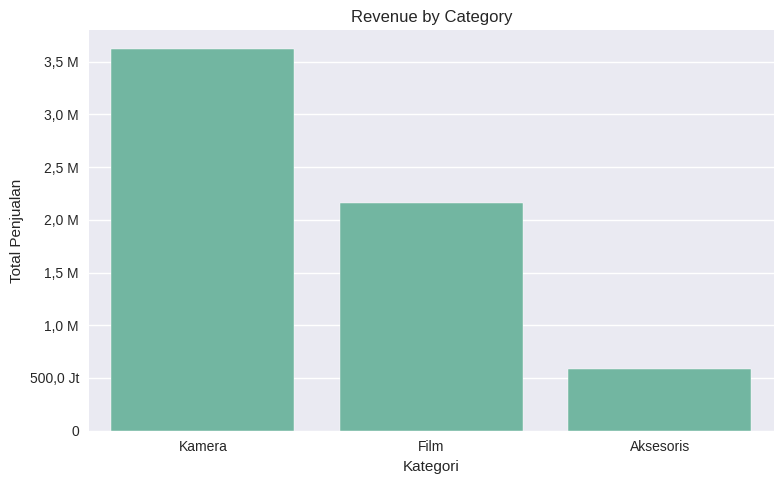

In [11]:
#Analisis pendapatan berdasarkan kategori produk

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

cat_rev = df.groupby("Kategori")["Total_Penjualan"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=cat_rev.index, y=cat_rev.values)

plt.title("Revenue by Category")
plt.xlabel("Kategori")
plt.ylabel("Total Penjualan")

def human_format(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}'.replace('.', ',') + ' M'   # miliaran
    elif x >= 1e6:
        return f'{x/1e6:.1f}'.replace('.', ',') + ' Jt'  # jutaan
    elif x >= 1e3:
        return f'{x/1e3:.0f} Rb'                         # ribuan
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

plt.tight_layout()
plt.show()

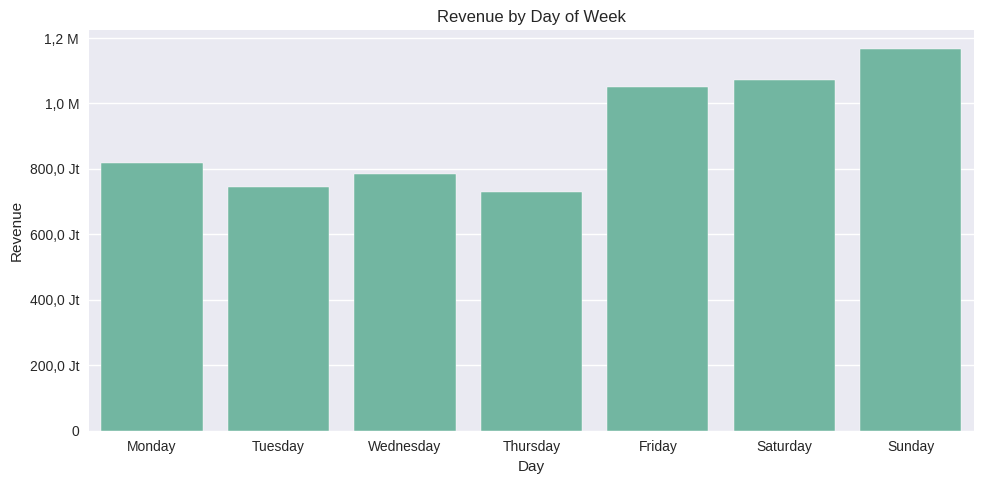

In [12]:
#Analisis pendapatan berdasarkan per hari
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df_day = df.groupby("Hari")["Total_Penjualan"].sum().reindex(day_order)

plt.figure(figsize=(10,5))
ax = sns.barplot(x=df_day.index, y=df_day.values)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

def human_format(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}'.replace('.', ',') + ' M'
    elif x >= 1e6:
        return f'{x/1e6:.1f}'.replace('.', ',') + ' Jt'
    elif x >= 1e3:
        return f'{x/1e3:.0f} Rb'
    else:
        return f'{x:.0f}'

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

plt.tight_layout()
plt.show()

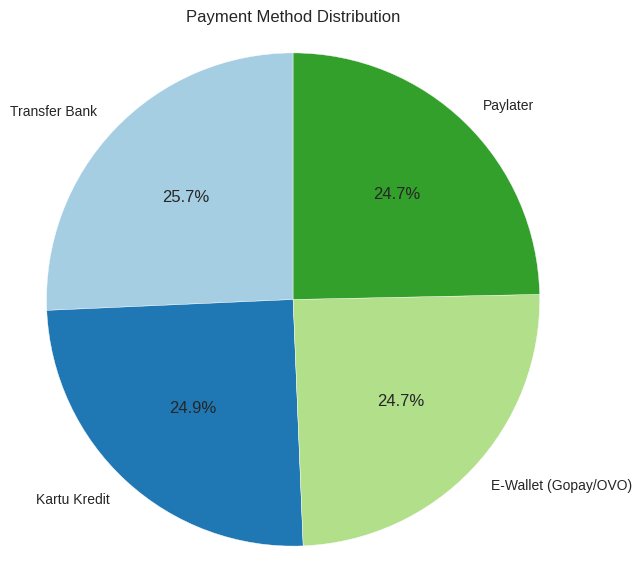

In [13]:
#Distribusi metode pembayaran dalam bentuk pie chart

import matplotlib.pyplot as plt

pay = df["Metode_Bayar"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(pay.values, labels=pay.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Payment Method Distribution")
plt.axis('equal')
plt.show()

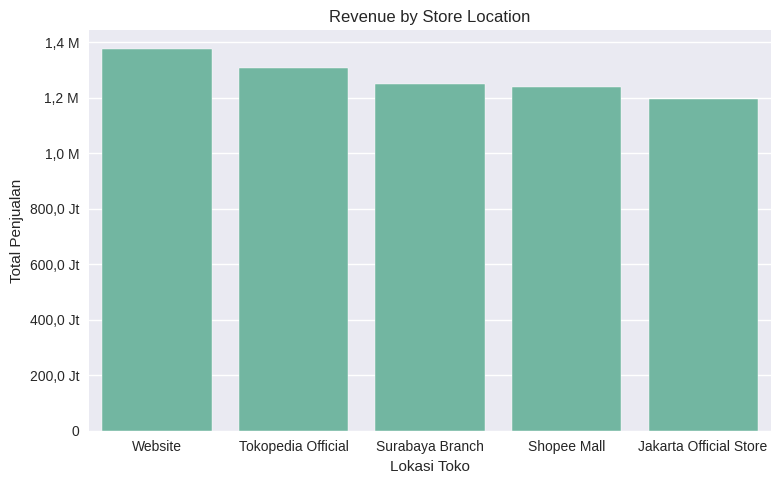

In [14]:
#Analisis pendapatan berdasarkan lokasi toko

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MultipleLocator

store_rev = df.groupby("Lokasi_Toko")["Total_Penjualan"].sum().sort_values(ascending=False)

def human_format(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}'.replace('.', ',') + ' M'
    elif x >= 1e6:
        return f'{x/1e6:.1f}'.replace('.', ',') + ' Jt'
    elif x >= 1e3:
        return f'{x/1e3:.0f} Rb'
    else:
        return f'{x:.0f}'

plt.figure(figsize=(8,5))
ax = sns.barplot(x=store_rev.index, y=store_rev.values)
plt.title("Revenue by Store Location")
plt.xlabel("Lokasi Toko")
plt.ylabel("Total Penjualan")

ax.yaxis.set_major_formatter(FuncFormatter(human_format))

plt.tight_layout()
plt.show()

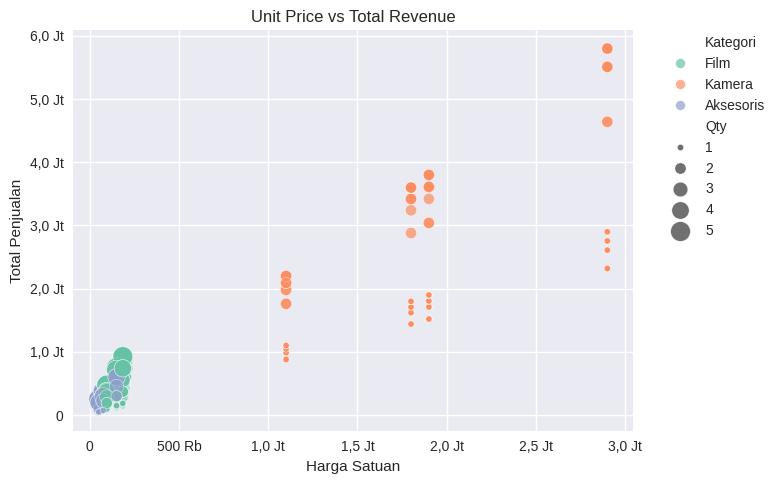

In [15]:
#Scatterplot hubungan harga satuan terhadap total penjualan

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

def human_format(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}'.replace('.', ',') + ' M'
    elif x >= 1e6:
        return f'{x/1e6:.1f}'.replace('.', ',') + ' Jt'
    elif x >= 1e3:
        return f'{x/1e3:.0f} Rb'
    else:
        return f'{x:.0f}'

plt.figure(figsize=(8,5))

ax = sns.scatterplot(
    data=df,
    x="Harga_Satuan",
    y="Total_Penjualan",
    size="Qty",
    hue="Kategori",
    alpha=0.7,
    palette="Set2",
    sizes=(20, 200)
)

plt.title("Unit Price vs Total Revenue")
plt.xlabel("Harga Satuan")
plt.ylabel("Total Penjualan")

ax.yaxis.set_major_formatter(FuncFormatter(human_format))
ax.xaxis.set_major_formatter(FuncFormatter(human_format))

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

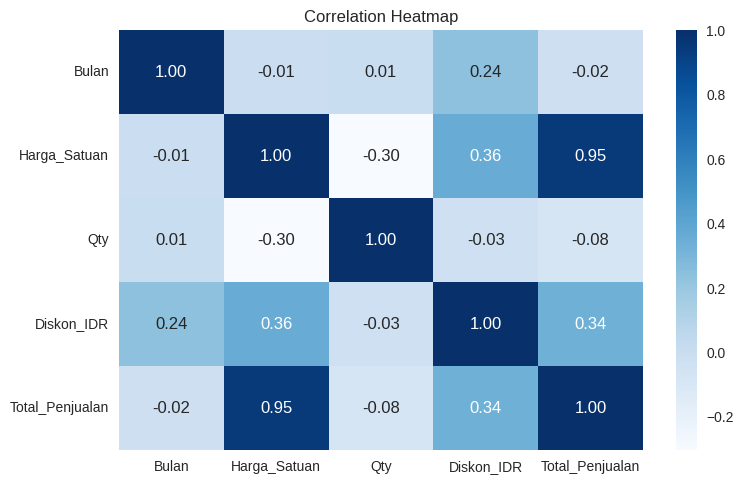

In [16]:
#Heatmap korelasi antara variabel numerik

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = [col for col in num_cols if col != "Tahun"]  # exclude Tahun

plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Data Preprocessing & Feature Engineering**

In [17]:
#Encoding data kategorikal

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Gunakan df hasil cleaning (dari Anggota 1)
print("Dataset shape:", df.shape)
df.head()

# Label Encoding untuk kategori dengan banyak unique values
label_cols = ["Nama_Produk", "Lokasi_Toko"]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Label Encoding applied on {col}")

# One-Hot Encoding untuk kategori kecil
onehot_cols = ["Kategori", "Metode_Bayar"]

df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)
print("One Hot Encoding applied on:", onehot_cols)

df.head()

Dataset shape: (12205, 12)
Label Encoding applied on Nama_Produk
Label Encoding applied on Lokasi_Toko
One Hot Encoding applied on: ['Kategori', 'Metode_Bayar']


,Tanggal,Tahun,Bulan,Hari,Nama_Produk,Lokasi_Toko,Harga_Satuan,Qty,Diskon_IDR,Total_Penjualan,Kategori_Film,Kategori_Kamera,Metode_Bayar_Kartu Kredit,Metode_Bayar_Paylater,Metode_Bayar_Transfer Bank
0,2022-05-01,2022,5,Sunday,5,3,185000,1,9250,175750,True,False,True,False,False
1,2022-05-01,2022,5,Sunday,5,3,185000,1,0,185000,True,False,True,False,False
2,2022-05-01,2022,5,Sunday,5,1,185000,2,0,370000,True,False,False,False,False
3,2022-05-01,2022,5,Sunday,2,1,1100000,1,0,1100000,False,True,False,True,False
5,2022-05-01,2022,5,Sunday,4,3,95000,1,4750,90250,True,False,True,False,False


In [18]:
# Konversi kolom tanggal ke format datetime
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# Feature date
df["Month"] = df["Tanggal"].dt.month
df["Day"] = df["Tanggal"].dt.day
df["Week"] = df["Tanggal"].dt.isocalendar().week

print("Date-based features created: Month, Day, Week")

#Pembuatan fitur Holiday_Flag berdasarkan daftar hari libur nasional
holiday_list = pd.to_datetime([
    "2023-01-01", "2023-06-01", "2023-12-25",
    "2024-01-01", "2024-06-01", "2024-12-25",
    "2025-01-01"
])

df["Holiday_Flag"] = df["Tanggal"].isin(holiday_list).astype(int)

print("Holiday Flag created.")

#Pembuatan fitur Diskon_Flag (1 jika ada diskon, 0 jika tidak)
df["Diskon_Flag"] = (df["Diskon_IDR"] > 0).astype(int)
print("Diskon_Flag created.")

#Pembuatan fitur Revenue_per_item (Total Penjualan ÷ Qty)
df["Revenue_per_item"] = df["Total_Penjualan"] / df["Qty"]
print("Revenue_per_item created.")

Date-based features created: Month, Day, Week
Holiday Flag created.
Diskon_Flag created.
Revenue_per_item created.


In [19]:
# Drop fitur leakage dari X
df = df.drop(columns=['Revenue_per_item'])
print("Revenue_per_item telah dihapus.")

Revenue_per_item telah dihapus.


In [20]:
#Membagi data menjadi dua

X = df.drop(["Total_Penjualan", "Tanggal"], axis=1)
y = df["Total_Penjualan"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train/Test Split Completed.")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Train/Test Split Completed.
X_train: (9764, 18)
X_test : (2441, 18)


In [21]:
#Scaling fitur numerik menggunakan StandardScaler

from sklearn.preprocessing import StandardScaler

num_features = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Scaling selesai untuk semua fitur numerik.")

Scaling selesai untuk semua fitur numerik.


**Modeling & Evaluation**

**1. LINEAR REGRESSION**

In [22]:
#Inisiasi model linear regression

from sklearn.preprocessing import StandardScaler

num_features = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Scaling selesai.")

Scaling selesai.


In [23]:
#Melakukan training model

from sklearn.linear_model import LinearRegression
import pandas as pd # Ensure pandas is imported

# One-hot encode the 'Hari' column
X_train_temp = pd.get_dummies(X_train, columns=['Hari'])
X_test_temp = pd.get_dummies(X_test, columns=['Hari'])

# Align columns - essential if some categories are not present in both train/test sets
# This creates a union of all column names from both encoded dataframes
all_columns = X_train_temp.columns.union(X_test_temp.columns)

# Reindex both dataframes to have the same columns and fill missing ones with 0
X_train_processed = X_train_temp.reindex(columns=all_columns, fill_value=0)
X_test_processed = X_test_temp.reindex(columns=all_columns, fill_value=0)

lr = LinearRegression()
lr.fit(X_train_processed, y_train)

print("Linear Regression Model Trained.")
print("Coefficients:", lr.coef_)
print("Intercept   :", lr.intercept_)

Linear Regression Model Trained.
Coefficients: [-4.96074484e+03 -4.24887801e+02  3.29363723e+03  7.14218108e+02
  7.32690884e+05  1.58934656e+05 -1.50600062e+04  4.68101415e+04
 -8.56202100e+03  2.35844560e+03 -4.57492855e+01 -1.95825534e+03
 -1.64293960e+03 -1.85839875e+01  3.89955818e+02 -2.22363476e+03
 -1.09983339e+04 -9.24360934e+03 -9.17370099e+02 -1.04853598e+03
 -2.82791663e+03  1.58418982e+03  5.30746859e+03  7.14577364e+03]
Intercept   : 497859.0528083351


In [24]:
#Prediksi total penjualan dengan data test

y_pred_lr = lr.predict(X_test_processed)
print("Prediction Berhasil.")

Prediction Berhasil.


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#Evaluasi linear regression
y_pred_train = lr.predict(X_train_processed)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

# Calculate test metrics for linear regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# === Print Hasil Training & Testing ===
print("=== Linear Regression Summary ===")

print("\n--- Training Result ---")
print("MAE  :", mae_train)
print("RMSE :", rmse_train)
print("R²   :", r2_train)

print("\n--- Testing Result ---")
print("MAE  :", mae_lr)
print("RMSE :", rmse_lr)
print("R²   :", r2_lr)

=== Linear Regression Summary ===

--- Training Result ---
MAE  : 62126.61690768484
RMSE : 165424.3571704874
R²   : 0.9446895675347237

--- Testing Result ---
MAE  : 64785.66400985439
RMSE : 177213.31603895323
R²   : 0.9368775288235681


**2. RANDOM FOREST**

In [26]:
#Import library untuk evaluasi metrik

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [27]:
#Inisialisasi model Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Melatih model menggunakan data training hasil preprocessing

rf.fit(X_train_processed, y_train)
print("Random Forest Model Trained.")

Random Forest Model Trained.


In [28]:
#Prediksi target pada data testing untuk evaluasi model

y_pred_rf = rf.predict(X_test_processed)
print("Random Forest Model Tested.")

Random Forest Model Tested.


In [29]:
#Prediksi data training agar tidak ovverfitting atau  underfitting

y_pred_train_rf = rf.predict(X_train_processed)

#Hitung metrik evaluasi di data training
mae_train_rf  = mean_absolute_error(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
r2_train_rf   = r2_score(y_train, y_pred_train_rf)


In [30]:
# Hitung metrik evaluasi di data testing
mae_test_rf   = mean_absolute_error(y_test, y_pred_rf)
rmse_test_rf  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_test_rf    = r2_score(y_test, y_pred_rf)

print("=== Random Forest Summary ===")

print("\n--- Training Result ---")
print("MAE  :", mae_train_rf)
print("RMSE :", rmse_train_rf)
print("R²   :", r2_train_rf)

print("\n--- Testing Result ---")
print("MAE  :", mae_test_rf)
print("RMSE :", rmse_test_rf)
print("R²   :", r2_test_rf)

=== Random Forest Summary ===

--- Training Result ---
MAE  : 157.19479721425645
RMSE : 3670.397686440938
R²   : 0.9999727708309781

--- Testing Result ---
MAE  : 541.4998975829578
RMSE : 9067.666428954655
R²   : 0.9998347344401881


**3. XG Boost**

In [31]:
#Install & import libraryxgboost
!pip install xgboost

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [32]:
#Inisialisasi model xgboost

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

In [33]:
#Melakukan training model

xgb.fit(X_train_processed, y_train)
print("XGBoost Model Trained.")

XGBoost Model Trained.


In [34]:
# Prediksi pada data training
y_pred_train_xgb = xgb.predict(X_train_processed)

# Hitung metrik training
mae_train_xgb  = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb   = r2_score(y_train, y_pred_train_xgb)

print("=== XGBoost Summary ===")

# Prediksi pada data testing
y_pred_xgb = xgb.predict(X_test_processed)

# Hitung metrik testing
mae_test_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_test_xgb   = r2_score(y_test, y_pred_xgb)

#Menampilkan Hasil
print("\n--- Training Result ---")
print("MAE  :", mae_train_xgb)
print("RMSE :", rmse_train_xgb)
print("R²   :", r2_train_xgb)

print("\n--- Testing Result ---")
print("MAE  :", mae_test_xgb)
print("RMSE :", rmse_test_xgb)
print("R²   :", r2_test_xgb)

=== XGBoost Summary ===

--- Training Result ---
MAE  : 345.884765625
RMSE : 622.7210701831118
R²   : 0.9999992251396179

--- Testing Result ---
MAE  : 1116.5927734375
RMSE : 7708.2441580427385
R²   : 0.9998805522918701


In [35]:
#Evaluasi perbandingan 3 model

import pandas as pd

comparison = pd.DataFrame([
    ["Linear Regression", mae_train, rmse_train, r2_train, mae_lr, rmse_lr, r2_lr],
    ["Random Forest", mae_train_rf, rmse_train_rf, r2_train_rf, mae_test_rf, rmse_test_rf, r2_test_rf],
    ["XGBoost", mae_train_xgb, rmse_train_xgb, r2_train_xgb, mae_test_xgb, rmse_test_xgb, r2_test_xgb]
],
columns=["Model", "Train MAE", "Train RMSE", "Train R²", "Test MAE", "Test RMSE", "Test R²"])

print(comparison)

               Model     Train MAE     Train RMSE  Train R²      Test MAE  \
0  Linear Regression  62126.616908  165424.357170  0.944690  64785.664010   
1      Random Forest    157.194797    3670.397686  0.999973    541.499898   
2            XGBoost    345.884766     622.721070  0.999999   1116.592773   

       Test RMSE   Test R²  
0  177213.316039  0.936878  
1    9067.666429  0.999835  
2    7708.244158  0.999881  


In [36]:
import pandas as pd

# copy dataframe utama
df_final = df.copy()

# pastikan kolom tanggal bertipe datetime
df_final['Tanggal'] = pd.to_datetime(df_final['Tanggal'])

# time features (meskipun sudah ada, ini buat konsistensi)
df_final['month'] = df_final['Tanggal'].dt.to_period('M').astype(str)
df_final['day_name'] = df_final['Tanggal'].dt.day_name()

# numeric safety
df_final['Harga_Satuan'] = pd.to_numeric(df_final['Harga_Satuan'], errors='coerce')
df_final['Qty'] = pd.to_numeric(df_final['Qty'], errors='coerce')
df_final['Diskon_IDR'] = pd.to_numeric(df_final['Diskon_IDR'], errors='coerce')
df_final['Total_Penjualan'] = pd.to_numeric(df_final['Total_Penjualan'], errors='coerce')

# revenue check (kalau mau konsisten secara logika)
df_final['Calculated_Revenue'] = (df_final['Harga_Satuan'] * df_final['Qty']) - df_final['Diskon_IDR']